# Lab 1
## Dynamic model of a multi-link manipulator

## Steps

### 0. Import the necessary libraries

In [2]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model (panda)

In [3]:
robot = rtb.models.DH.Panda()
print(robot)

DHRobot: Panda (by Franka Emika), 7 joints (RRRRRRR), dynamics, geometry, modified DH parameters
┌─────────┬────────┬─────┬───────┬─────────┬────────┐
│  aⱼ₋₁   │  ⍺ⱼ₋₁  │ θⱼ  │  dⱼ   │   q⁻    │   q⁺   │
├─────────┼────────┼─────┼───────┼─────────┼────────┤
│     0.0 │   0.0° │  q1 │ 0.333 │ -166.0° │ 166.0° │
│     0.0 │ -90.0° │  q2 │   0.0 │ -101.0° │ 101.0° │
│     0.0 │  90.0° │  q3 │ 0.316 │ -166.0° │ 166.0° │
│  0.0825 │  90.0° │  q4 │   0.0 │ -176.0° │  -4.0° │
│ -0.0825 │ -90.0° │  q5 │ 0.384 │ -166.0° │ 166.0° │
│     0.0 │  90.0° │  q6 │   0.0 │   -1.0° │ 215.0° │
│   0.088 │  90.0° │  q7 │ 0.107 │ -166.0° │ 166.0° │
└─────────┴────────┴─────┴───────┴─────────┴────────┘

┌──────┬───────────────────────────────────────┐
│ tool │ t = 0, 0, 0.1; rpy/xyz = -45°, 0°, 0° │
└──────┴───────────────────────────────────────┘

┌──────┬─────┬────────┬─────┬───────┬─────┬───────┬──────┐
│ name │ q0  │ q1     │ q2  │ q3    │ q4  │ q5    │ q6   │
├──────┼─────┼────────┼─────┼───────┼─────

### 2. Fill in the parameters of the robot model (in the example, filled in for the Puma560 robot)

0. Using dyn() you can view the dynamic parameters of each link

In [61]:
print(robot.links[6].dyn())  # initial dynamic parameters of the first link

m     =      0.74 
r     =         0        0        0 
        |    0.013 -0.00043  -0.0012 | 
I     = | -0.00043     0.01 -0.00074 | 
        |  -0.0012 -0.00074   0.0048 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =      -2.9 to      2.9


1. Let's define the mass of the links

In [ ]:
# the mass for each link were obtained directly from the Robotics Toolbox model
robot.links[0].m = 5
robot.links[1].m = 2.34471
robot.links[2].m = 2.36414
robot.links[3].m = 2.38050
robot.links[4].m = 2.42754
robot.links[5].m = 3.49611
robot.links[6].m = 1.46736

2. Let's define the center of mass of each link

In [ ]:
# For the center of mass vectors (r), the toolbox output showed
# zero values for all links in the adopted model. However, for
# practical modeling non-zero center-of-mass values were selected 
# These values are chosen to be physically consistent with the relative size

robot.links[0].r = [ 0.00033, -0.02204, -0.04762]
robot.links[1].r = [ 0.00038, -0.09211,  0.01908]
robot.links[2].r = [ 0.05152,  0.01696, -0.02971]
robot.links[3].r = [-0.05113,  0.05825,  0.01698]
robot.links[4].r = [-0.00005,  0.03730, -0.09280]
robot.links[5].r = [ 0.06572, -0.00371,  0.00153]
robot.links[6].r = [ 0.00089, -0.00044,  0.05491]

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [ ]:
# the inertia tensor for each link were obtained directly from the Robotics Toolbox model
robot.links[0].I = [0.7,   0.71,  0.0091, -0.00014,  0.019,    0.0068]
robot.links[1].I = [0.008, 0.028, 0.026,  -0.0039,   0.0007,   0.01]
robot.links[2].I = [0.037, 0.036, 0.011,  -0.0048,  -0.013,   -0.011]
robot.links[3].I = [0.026, 0.02,  0.028,   0.0078,   0.0086,  -0.0013]
robot.links[4].I = [0.036, 0.029, 0.0086, -0.0021,   0.00023, -0.004]
robot.links[5].I = [0.002, 0.0044,0.0054,  0.00011,  0.00034, -0.0012]
robot.links[6].I = [0.013, 0.01,  0.0048, -0.00043, -0.00074, -0.0012]

4. Let's set the moment of inertia of the drive

In [65]:
robot.links[0].Jm = 2e-4
robot.links[1].Jm = 2e-4
robot.links[2].Jm = 1.5e-4
robot.links[3].Jm = 1.5e-4
robot.links[4].Jm = 1e-4
robot.links[5].Jm = 1e-4
robot.links[6].Jm = 5e-5

5. Let's define the coefficient of viscous friction of the drive

In [ ]:
# The viscous friction coefficients (B) were chosen as reasonable
# approximate values to provide a physically consistent dynamic
# behavior. These values are not directly extracted from dyn(),
# but selected to match the relative joint loading 
robot.links[0].B = 0.7
robot.links[1].B = 1.9
robot.links[2].B = 1.5
robot.links[3].B = 1.7
robot.links[4].B = 1.7
robot.links[5].B = 1.2
robot.links[6].B = 1.4

6. Let's define the coefficient of Coulomb friction of the drive

In [67]:
robot.links[0].Tc = [0.2, -0.2]
robot.links[1].Tc = [0.3, -0.3]
robot.links[2].Tc = [0.25, -0.25]
robot.links[3].Tc = [0.35, -0.35]
robot.links[4].Tc = [0.2, -0.2]
robot.links[5].Tc = [0.15, -0.15]
robot.links[6].Tc = [0.1, -0.1]

7. Let's set the gear ratio for each link

In [ ]:
# The gear ratio (G) was set to 1 for all joints, which is a
# standard simplifying assumption in the absence of published
# actuator transmission data.
robot.links[0].G = 1
robot.links[1].G = 1
robot.links[2].G = 1
robot.links[3].G = 1
robot.links[4].G = 1
robot.links[5].G = 1

8. Let's set restrictions on the generalized coordinates for each link

In [ ]:
#joint limits (qlim)
# were obtained from the Robotics Toolbox dynamic parameter
robot.links[0].qlim = [-2.9, 2.9]
robot.links[1].qlim = [-1.8, 1.8]
robot.links[2].qlim = [-2.9, 2.9]
robot.links[3].qlim = [-3.1,-0.07]
robot.links[4].qlim = [-2.9, 2.9]
robot.links[5].qlim = [-0.018 , 3.8]
robot.links[6].qlim = [-2.9, 2.9]

### 3. Set the initial and final positions of the robot and plot them

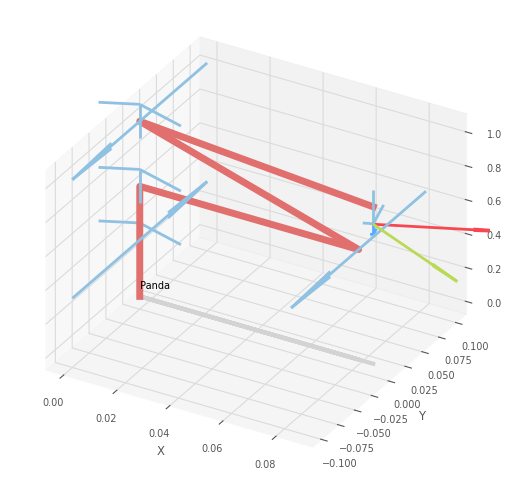

<Figure size 640x480 with 0 Axes>

In [71]:
q_start = [0, 0, 0, 0, 0, 0 ,0]
robot.plot(q_start)
plt.show()

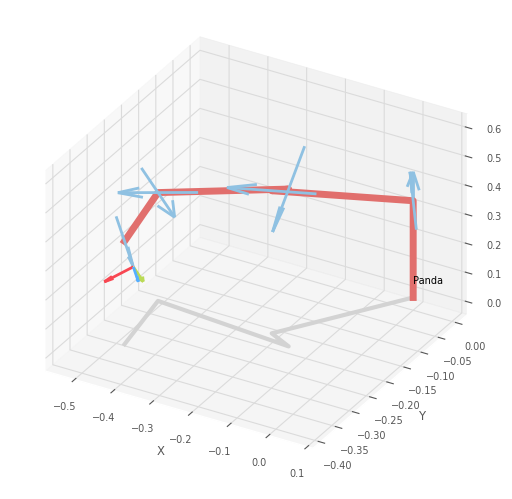

<Figure size 640x480 with 0 Axes>

In [72]:
q_end = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4 ,  pi/4]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions

In [73]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)

### 5. Solve the inverse dynamics

In [77]:
tau = robot.rne(tr.q, tr.qd, tr.qdd).T

tau0 = robot.rne(tr.q, np.zeros([N,7]), np.zeros([N,7])).T

tau1 = robot.rne(tr.q, tr.qd, np.zeros([N,7])).T

### 6. Obtain the components of the dynamic equation

In [78]:
M = robot.inertia(tr.q)
C = robot.coriolis(tr.q, tr.qd)
G = robot.gravload(tr.q)

M0 = robot.inertia(tr.q)
C0 = robot.coriolis(tr.q, np.zeros([N,7]))
G0 = robot.gravload(tr.q)

### 7. Plot the graphs

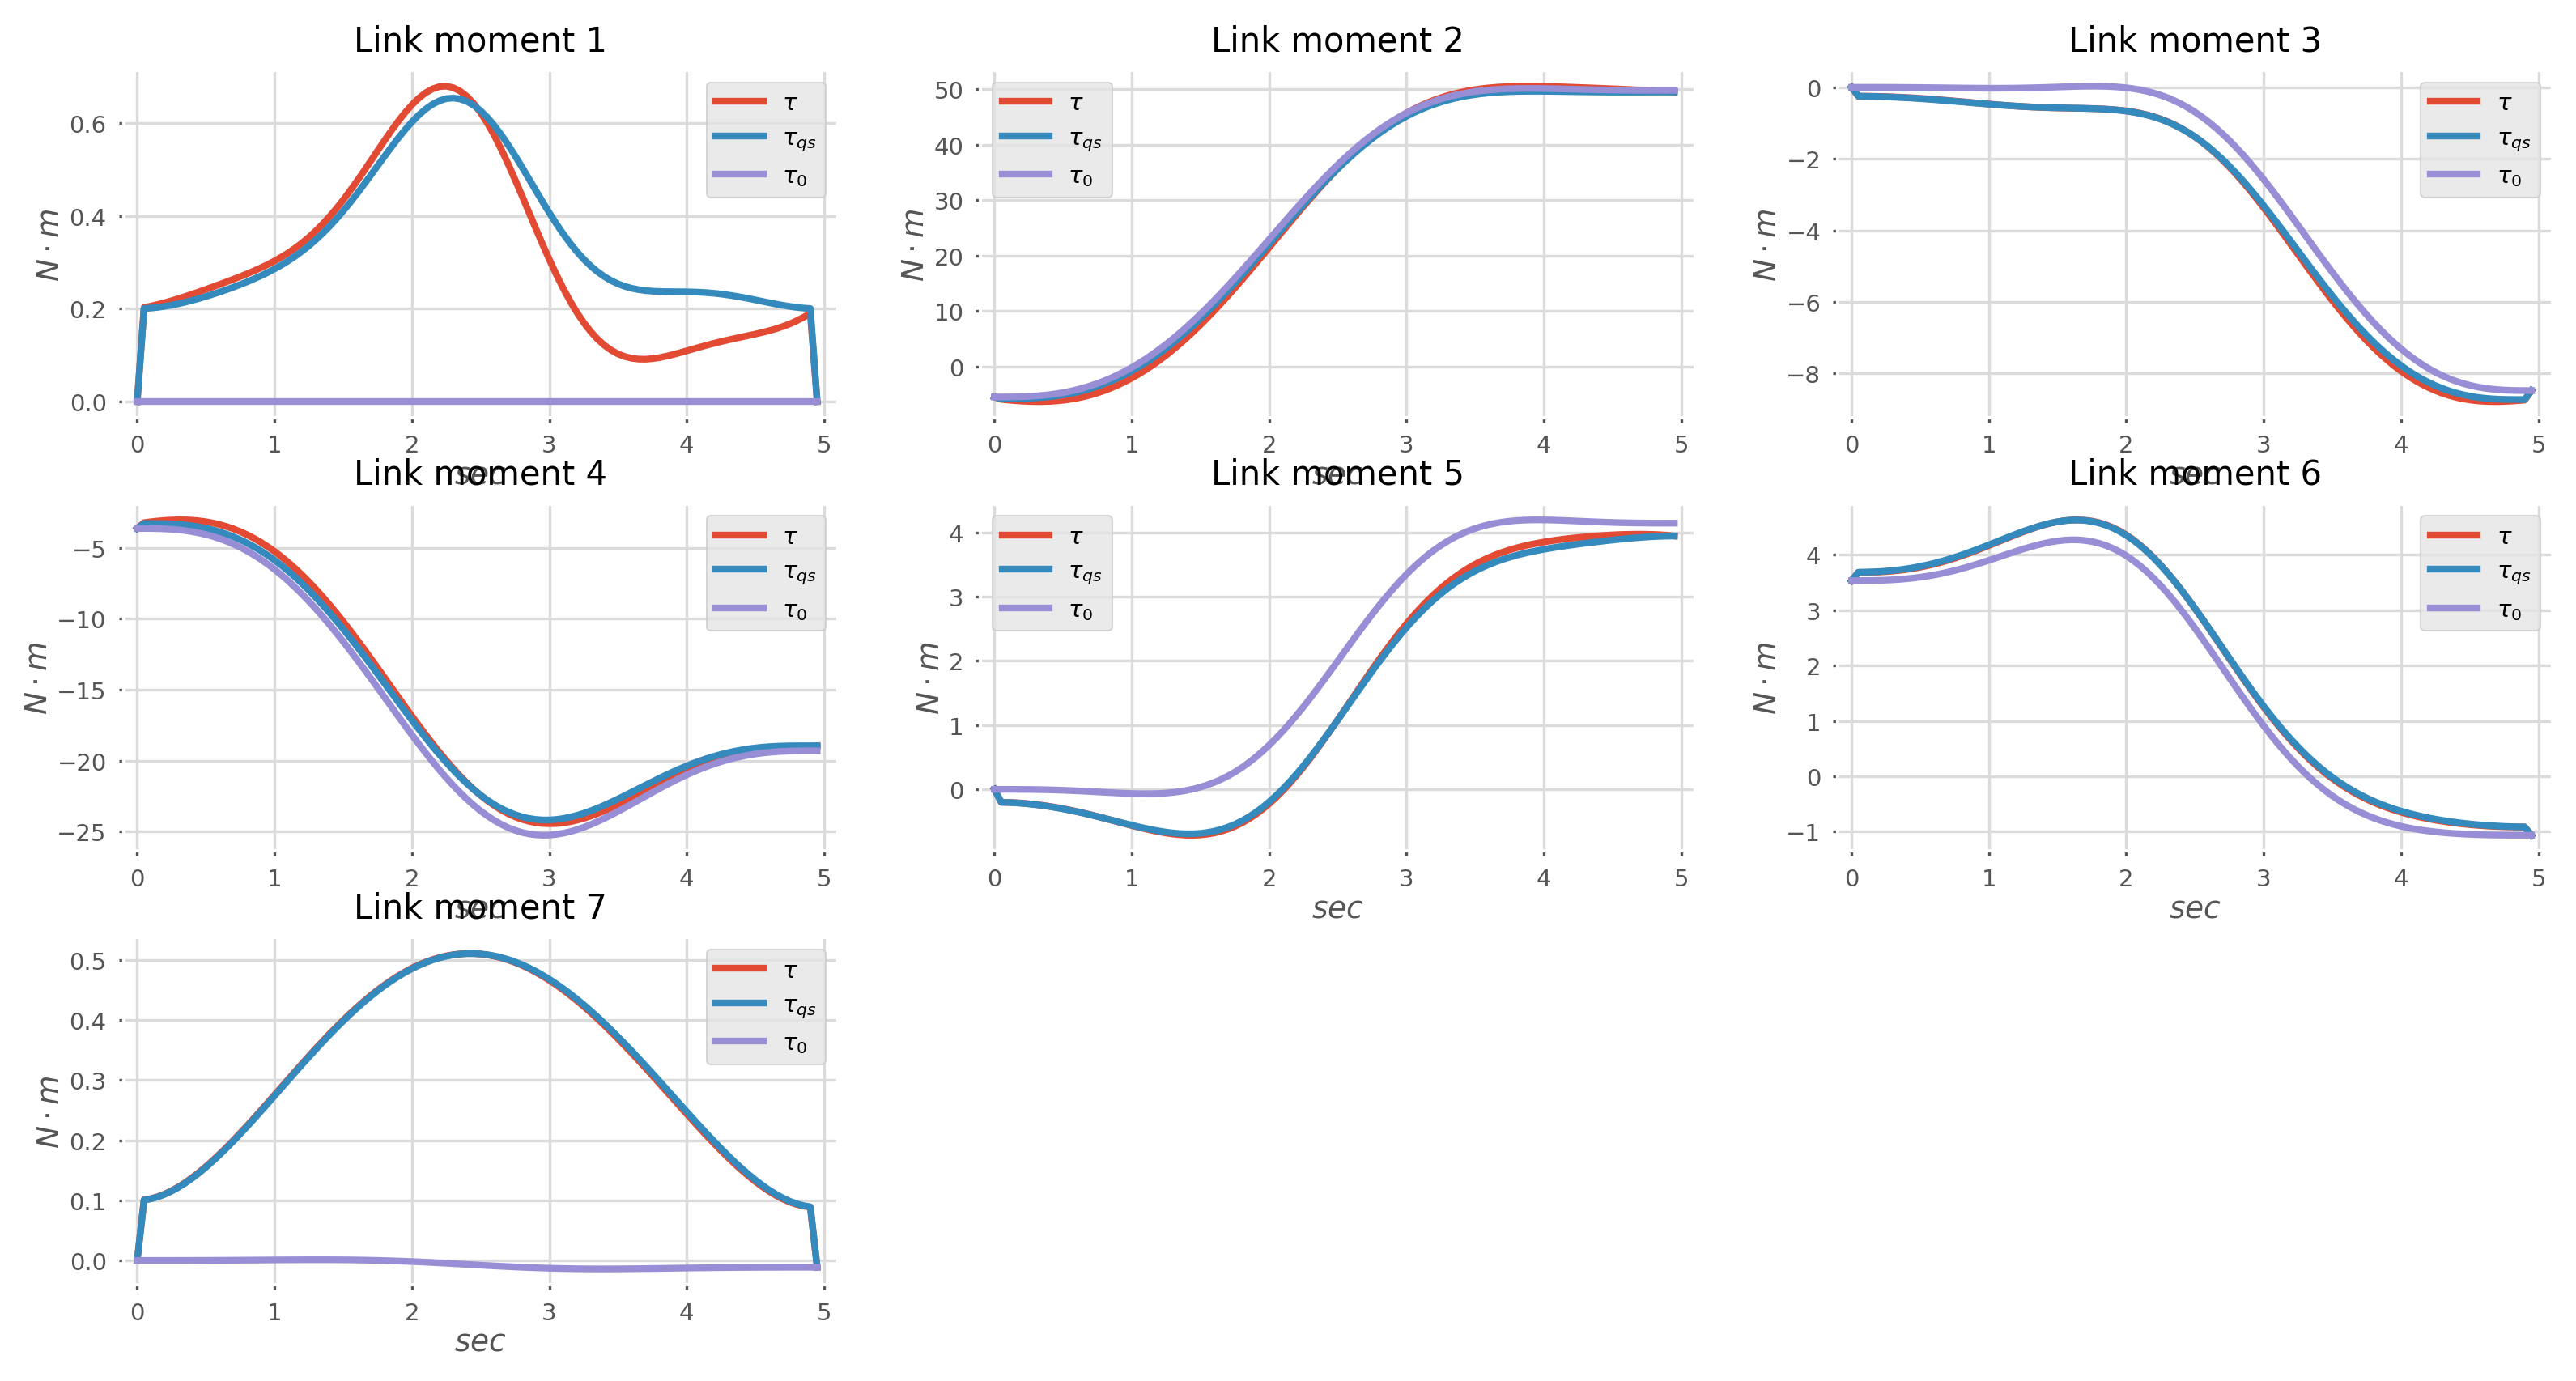

In [81]:
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(7):
    plt.subplot(3,3,g+1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    plt.plot(time, tau[g], linewidth=2, label=r"$\tau$")  # Строим график
    plt.plot(time, tau1[g], linewidth=2, label=r"$\tau_{qs}$")  # Строим график
    plt.plot(time, tau0[g], linewidth=2, label=r"$\tau_{0}$")  # Строим график
    plt.title(r"Link moment {}".format(g+1), fontsize=10)  # Название графика
    plt.ylabel(r"$N \cdot m$", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$sec$", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()

The torque profiles for all joints are smooth and continuous

For most joints, the total torque τ closely follows the gravitational component τ
Gravity is the dominant contributor to joint torques in this motion.
